<a href="https://colab.research.google.com/github/Anoop7485/ML-projects/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING DEPENDENCIES

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics



DATA COLLECTION AND PREPROCESSING

In [ ]:
df=pd.read_csv('/content/car data.csv')

In [ ]:
print(df)

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  
0        Dealer       Manual      0  
1        Dealer       Manual      0

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
#checking no of rows and columns
df.shape

(301, 9)

In [ ]:
#getting information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
#checking null values in dataset
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
#checking distribution of categorical data
print(df.Fuel_Type.value_counts())
print(df.Seller_Type.value_counts())
print(df.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


ENCODING CATEGORICAL DATA

In [ ]:
#encoding fueltype
df.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
#encoding of sellertype
df.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
#encoding of transmission
df.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)



<ipython-input-41-98257bb206ce>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
<ipython-input-41-98257bb206ce>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)


splitting data into run and target

In [ ]:
x=df.drop(['Car_Name','Selling_Price'],axis=1)
y=df['Selling_Price']

In [ ]:
print(x)

     Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  \
0    2014           5.59       27000          0            0             0   
1    2013           9.54       43000          1            0             0   
2    2017           9.85        6900          0            0             0   
3    2011           4.15        5200          0            0             0   
4    2014           6.87       42450          1            0             0   
..    ...            ...         ...        ...          ...           ...   
296  2016          11.60       33988          1            0             0   
297  2015           5.90       60000          0            0             0   
298  2009          11.00       87934          0            0             0   
299  2017          12.50        9000          1            0             0   
300  2016           5.90        5464          0            0             0   

     Owner  
0        0  
1        0  
2        0  
3        0 

In [ ]:
print(y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


SPLITTING  DATASET INTO TRAIN AND TEST

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=2)


MODEL TRAINIED

1.LINEAR REGRESSION

In [ ]:
#setting linear regression
lin_reg_model=LinearRegression()

In [ ]:
lin_reg_model.fit(x_train,y_train)#fitting the train of x and y

LinearRegression()

In [ ]:
#prediction on training dataset
training_data_prediction=lin_reg_model.predict(x_train)

In [ ]:
#R squared Error
error_score=metrics.r2_score(y_train,training_data_prediction)
print("R squared Error:",error_score)

R squared Error: 0.8799451660493711


VISULAZIE THE ACTUAL PRICES AND PREDICTED PRICES FOR TRAINED DATA USING LINEAR REGRESSION

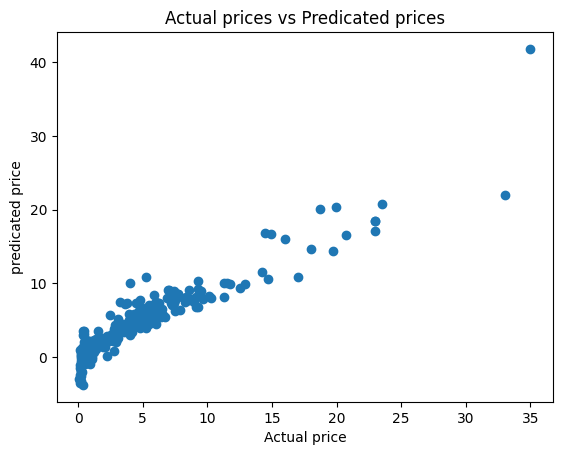

In [ ]:
plt.scatter(y_train,training_data_prediction)
plt.xlabel("Actual price")
plt.ylabel("predicated price")
plt.title("Actual prices vs Predicated prices")
plt.show()

In [ ]:
test_data_prediction=lin_reg_model.predict(x_test)#test the data


In [ ]:
#test_data_prediction=lin_reg_model.predict(x_test)#test the data
error_score1=metrics.r2_score(y_train,training_data_prediction)
print("R squared Error:",error_score1)

R squared Error: 0.8799451660493711


VISULAZIE ACTUALPRICES AND EXCEPTEDPRICES USING LINEARREGRESSION FOR TEST DATA

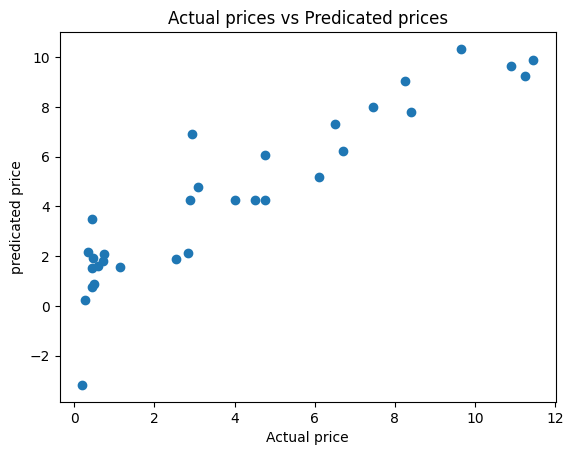

In [ ]:
plt.scatter(y_test,test_data_prediction)
plt.xlabel("Actual price")
plt.ylabel("predicated price")
plt.title("Actual prices vs Predicated prices")
plt.show()

2.LASSO REGRESSION

MODEL EVALUTION

In [ ]:
#setting linear regression
lin_reg_model=Lasso()

In [ ]:
lin_reg_model.fit(x_train,y_train)

Lasso()

In [ ]:
training_data_prediction1=lin_reg_model.predict(x_train)

In [ ]:
#R squared Error
error_score=metrics.r2_score(y_train,training_data_prediction1)
print("R squared Error:",error_score)

R squared Error: 0.8427856123435794


VISUALIZE THE PREDICTED PRICES VS ACTUAL PRICES USING LASSO REGRESSION FOR TRAINING DATA

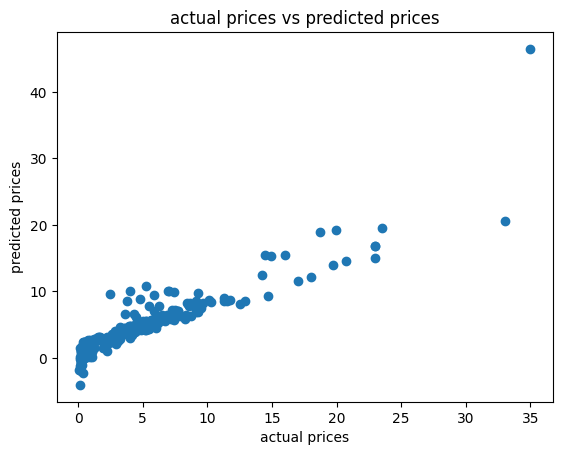

In [ ]:
plt.scatter(y_train,training_data_prediction1)
plt.xlabel('actual prices')
plt.ylabel("predicted prices")
plt.title("actual prices vs predicted prices")
plt.show()

In [ ]:
test_data_prediction1=lin_reg_model.predict(x_test)#test the data


In [ ]:
error_score=metrics.r2_score(y_train,training_data_prediction)
print("R squared Error:",error_score)

R squared Error: 0.8799451660493711


VISUALIZE THE TEST DATA USING LASSO REGRESSION

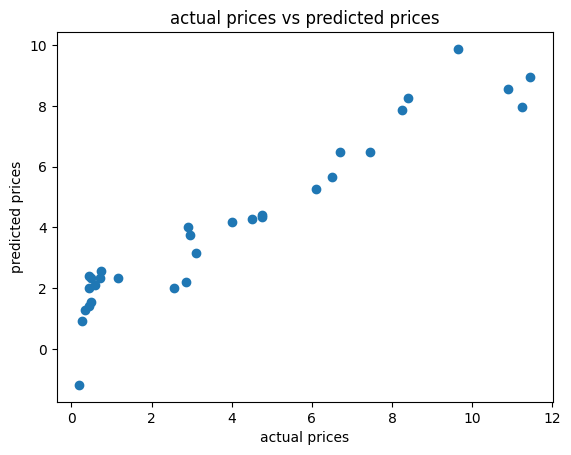

In [ ]:
plt.scatter(y_test,test_data_prediction1)
plt.xlabel('actual prices')
plt.ylabel("predicted prices")
plt.title("actual prices vs predicted prices")
plt.show()